# Task 3 — Analisi esplorativa di `training.csv`

> 📄 Documentazione completa e motivazioni: [`docs/task3.md`](../docs/task3.md)

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")   # stile usato nei notebook del corso

In [2]:
df = pd.read_csv("../data/processed/training.csv")
print(f"Dataset: {df.shape[0]} istanze x {df.shape[1]} attributi")
df.head()

Dataset: 41176 istanze x 21 attributi


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [3]:
# Separiamo attributi numerici e nominali (Lezione 3)
numeriche = df.select_dtypes(include=np.number).drop(columns="y").columns.tolist()
nominali  = df.select_dtypes(exclude=np.number).columns.tolist()
print("Numeriche:", numeriche)
print("Nominali:", nominali)

Numeriche: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Nominali: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 1. Verifica di osservazioni errate

### 1.1 Statistiche descrittive e valori impossibili

In [4]:
df[numeriche].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
age,40.02,10.42,17.00,98.00
duration,258.32,259.31,0.00,4918.00
campaign,2.57,2.77,1.00,56.00
pdays,962.46,186.94,0.00,999.00
previous,0.17,0.49,0.00,7.00
emp.var.rate,0.08,1.57,-3.40,1.40
cons.price.idx,93.58,0.58,92.20,94.77
cons.conf.idx,-40.50,4.63,-50.80,-26.90
euribor3m,3.62,1.73,0.63,5.04
nr.employed,5167.03,72.25,4963.60,5228.10


### 1.2 Il codice speciale di `pdays`

In [5]:
quota_999 = (df["pdays"] == 999).mean()
print(f"pdays = 999 ('mai contattato prima'): {quota_999:.1%} delle istanze")

pdays = 999 ('mai contattato prima'): 96.3% delle istanze


### 1.3 Valori mancanti (`unknown`)

In [6]:
unknown_per_attr = df[nominali].apply(lambda c: (c == "unknown").sum())
unknown_per_attr[unknown_per_attr > 0].sort_values(ascending=False)

default      8596
education    1730
housing       990
loan          990
job           330
marital        80
dtype: int64

### 1.4 Duplicati

In [7]:
print("Righe duplicate residue:", df.duplicated().sum())

Righe duplicate residue: 0


### 1.5 Outlier estremi

In [8]:
print(f"campaign max = {df['campaign'].max()} contatti nella stessa campagna")
print(f"duration max = {df['duration'].max()} sec ({df['duration'].max()/60:.0f} minuti)")

campaign max = 56 contatti nella stessa campagna
duration max = 4918 sec (82 minuti)


## 2. Boxplot degli attributi numerici

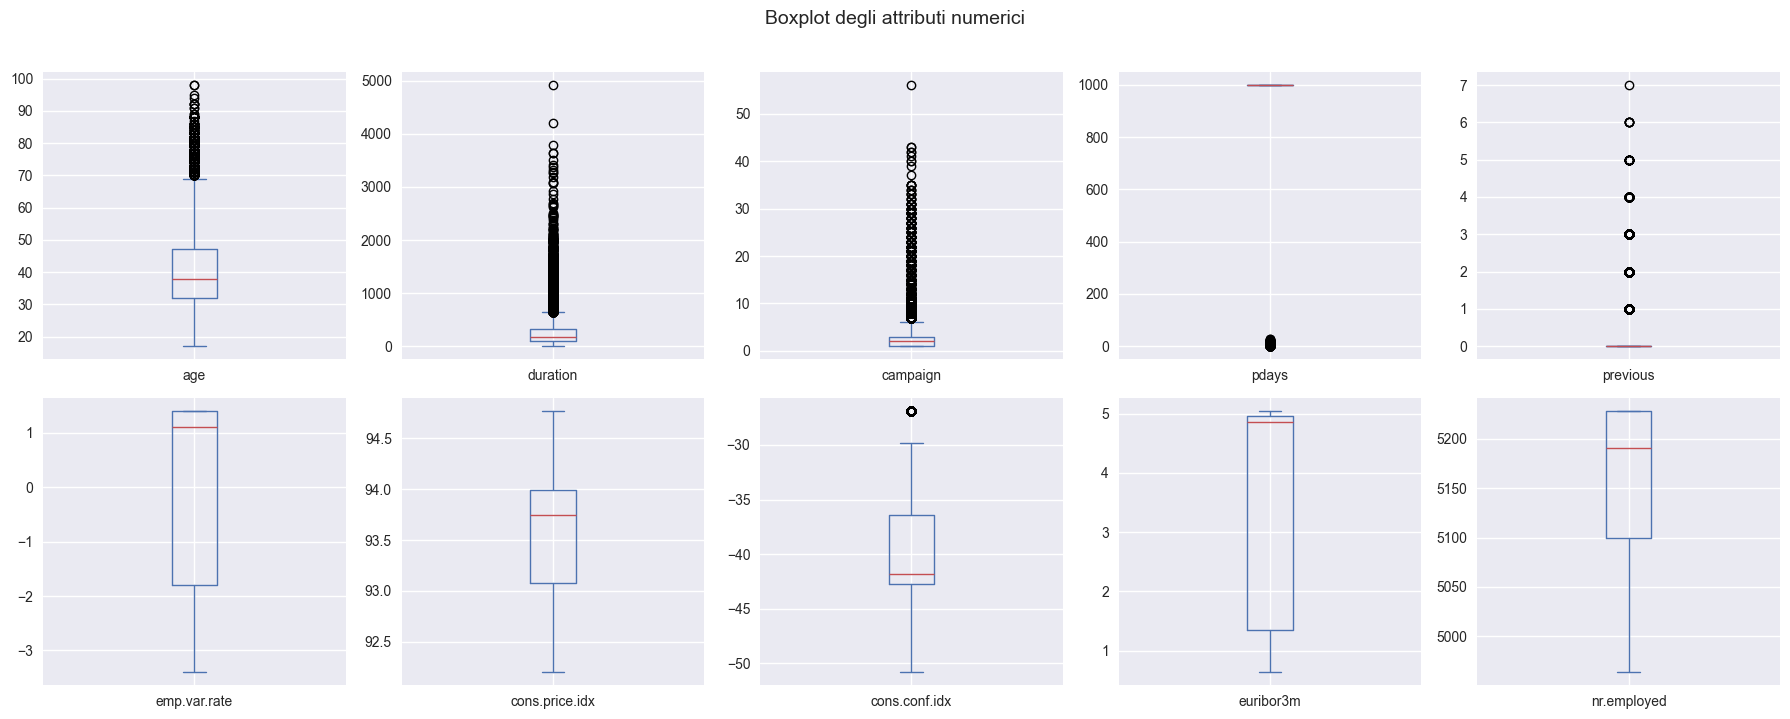

In [9]:
df[numeriche].plot(kind="box", subplots=True, layout=(2, 5),
                   figsize=(18, 7), sharex=False, sharey=False)
plt.suptitle("Boxplot degli attributi numerici", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Matrice di correlazione

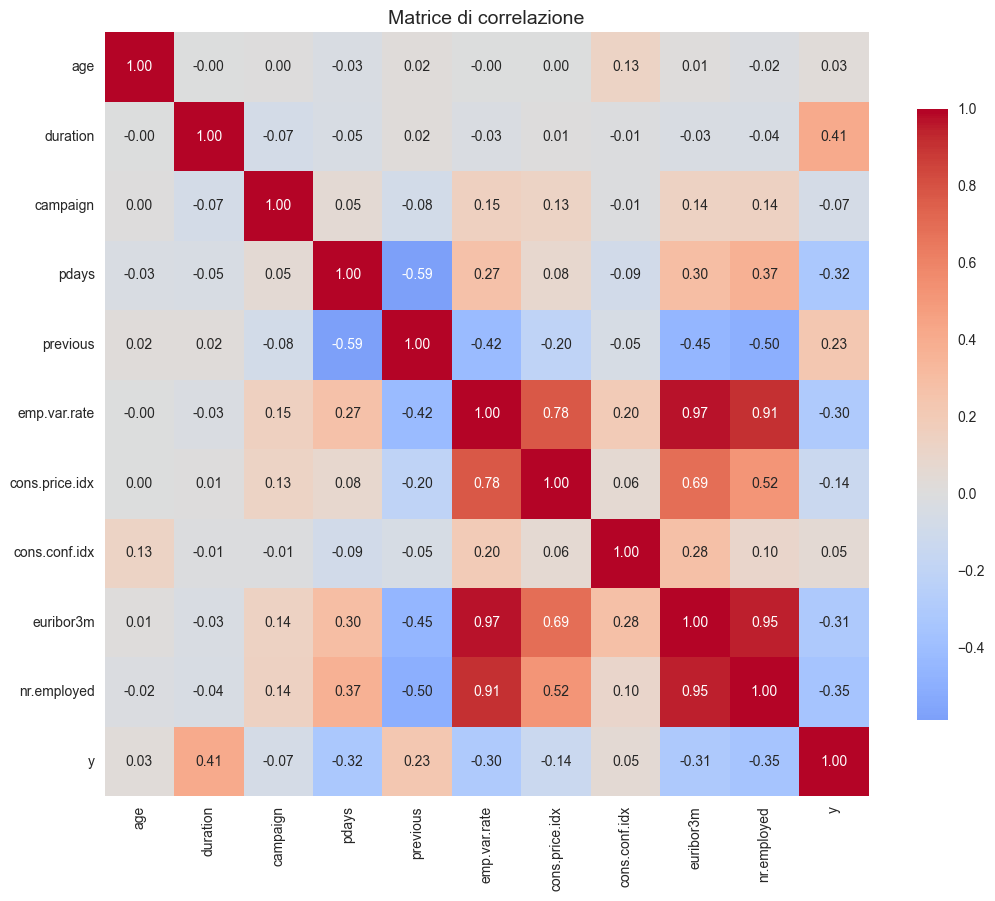

In [10]:
corr = df[numeriche + ["y"]].corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Matrice di correlazione", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1 Correlazione con il target

In [11]:
corr["y"].drop("y").sort_values(ascending=False).round(3)

duration          0.405
previous          0.230
cons.conf.idx     0.055
age               0.030
campaign         -0.066
cons.price.idx   -0.136
emp.var.rate     -0.298
euribor3m        -0.308
pdays            -0.325
nr.employed      -0.355
Name: y, dtype: float64

## 4. Pairplot

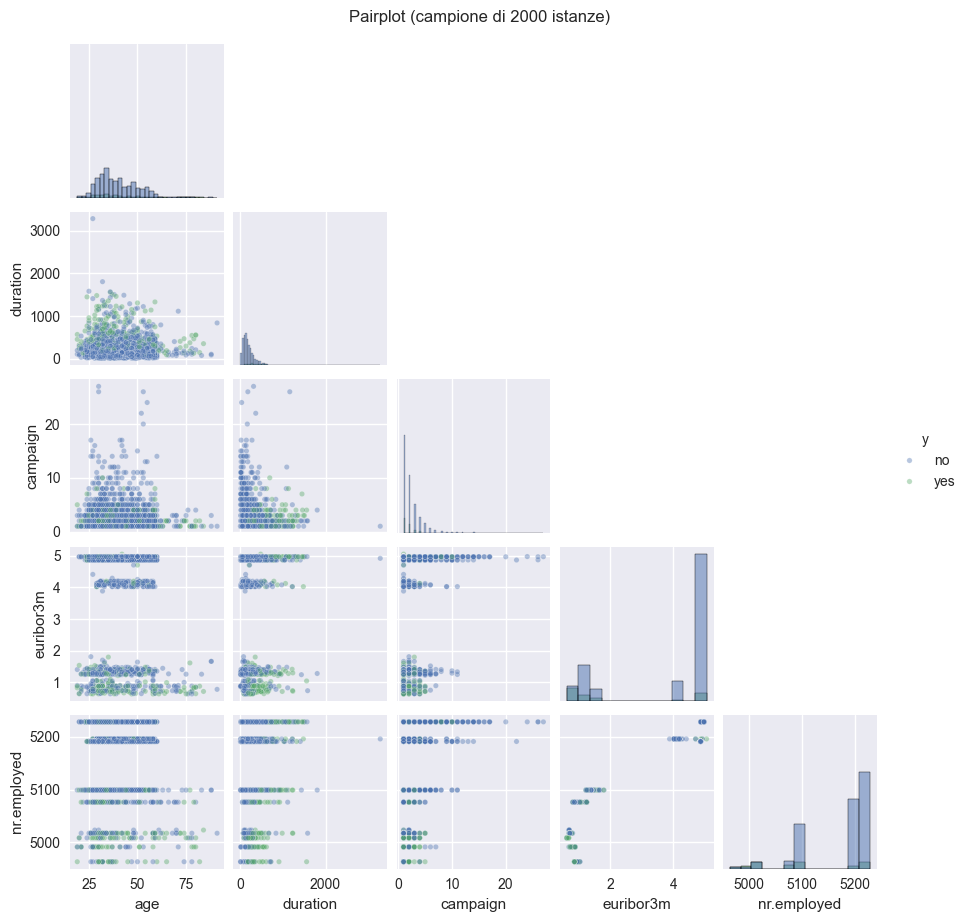

In [12]:
sub = ["age", "duration", "campaign", "euribor3m", "nr.employed", "y"]
dfp = df[sub].copy()
dfp["y"] = dfp["y"].map({0: "no", 1: "yes"})
campione = dfp.sample(2000, random_state=10)

g = sns.pairplot(campione, hue="y", diag_kind="hist",
                 plot_kws={"alpha": 0.4, "s": 15}, height=1.8, corner=True)
g.fig.suptitle("Pairplot (campione di 2000 istanze)", y=1.02)
plt.show()

## 5. Analisi degli attributi nominali

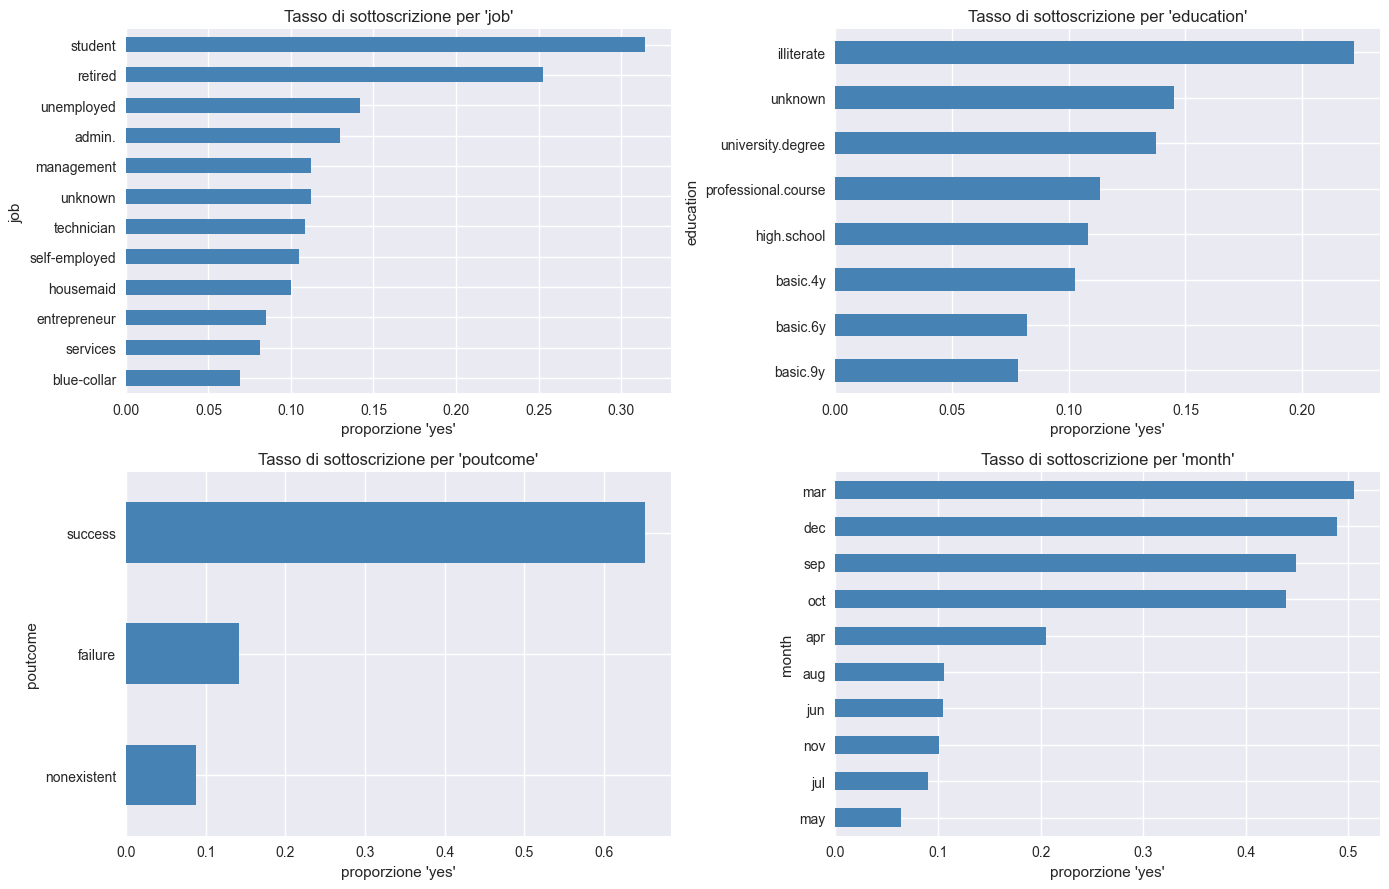

In [13]:
# Tasso di 'yes' per alcune nominali chiave
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def barplot_tasso(attr, ax):
    (df.groupby(attr)["y"].mean().sort_values()
       .plot(kind="barh", ax=ax, color="steelblue"))
    ax.set_title(f"Tasso di sottoscrizione per '{attr}'")
    ax.set_xlabel("proporzione 'yes'")

attrs = pd.Series(["job", "education", "poutcome", "month"])
attrs.reset_index().apply(
    lambda r: barplot_tasso(r[0], axes.flat[r["index"]]), axis=1)
plt.tight_layout()
plt.show()

In [14]:
# Esempio numerico: poutcome e' molto informativo
df.groupby("poutcome")["y"].mean().sort_values(ascending=False).round(3)

poutcome
success        0.651
failure        0.142
nonexistent    0.088
Name: y, dtype: float64

---
## Riepilogo

- **Nessuna osservazione palesemente errata**: nessun valore impossibile, nessun
  duplicato. Da interpretare: il codice `pdays=999` ("mai contattato") e i valori
  `unknown` (mancanti).
- **`duration`** è il più correlato col target ma va **escluso** dal modello (data
  leakage): lo faremo nel Task 5.
- Forte **multicollinearità** tra le variabili economiche.
- Attributi nominali molto informativi: **`poutcome`**, `contact`, `month`.

**Prossimo passo (Task 4):** valutare i classificatori manuali (1R e Naïve Bayes) su
`training.csv` o suoi sottoinsiemi, cercando di ottimizzarne le prestazioni.